# Taller — Regresión logística
## Caso: abandono de producto financiero

**Curso:** Machine Learning en Economía y Finanzas · FCEA · Clase 9 · 2026-2

Este cuaderno está orientado al archivo `abandono_producto_financiero.csv` que se encuentra en la misma carpeta del proyecto. La variable respuesta es binaria: `abandono = 1` si el cliente cerró la relación y `abandono = 0` si permanece.

La idea es estimar:

$$
P(\text{abandono} = 1 \mid x) = \Lambda(x\beta)
$$

con `statsmodels` usando `smf.logit` y comparando con un ajuste OLS como referencia.


# Punto 1. Estructura de los datos

En esta parte revisamos la base como un conjunto de observaciones; confirmamos la unidad de análisis, la variable dependiente, el número de filas y columnas, los tipos de variables y los vacíos. Esto permite validar que el dataset es compatible con el modelo logit antes de estimar.


In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = False

# Cargar la base que está en la misma carpeta del proyecto
NOTEBOOK_DIR = Path.cwd()
DATA_CANDIDATES = [
    NOTEBOOK_DIR / "abandono_producto_financiero.csv",
    NOTEBOOK_DIR / "abandono_producto_financiero.xlsx",
    NOTEBOOK_DIR / "abandono_producto_financiero.xls",
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        f"No se encontró la base de datos en {NOTEBOOK_DIR}. "
        "Verifica que el archivo CSV o Excel esté en la misma carpeta que este notebook."
    )

if DATA_PATH.suffix.lower() == ".csv":
    df = pd.read_csv(DATA_PATH)
else:
    df = pd.read_excel(DATA_PATH)

# Se asume que la respuesta binaria se llama abandono
if "abandono" in df.columns:
    df["abandono"] = df["abandono"].astype(int)

# Vista inicial de los datos
print(f"Archivo cargado: {DATA_PATH.name}")
print(f"Forma del DataFrame: {df.shape}")
df.head()


Archivo cargado: abandono_producto_financiero.csv
Forma del DataFrame: (10000, 14)


,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
0,1,15634602,Hargrave,619,Francia,Mujer,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,España,Mujer,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,Francia,Mujer,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,Francia,Mujer,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,España,Mujer,43,2,125510.82,1,1,1,79084.10,0


In [2]:
# Punto 1: inspección de la estructura
print("Columnas:")
print(df.columns.tolist())
print("\nTipos de variables:")
print(df.dtypes)
print("\nNúmero de nulos por columna:")
print(df.isna().sum())
print("\nResumen de la variable respuesta:")
print(df["abandono"].value_counts(dropna=False))
print("\nProporción de la variable respuesta:")
print(df["abandono"].value_counts(normalize=True, dropna=False))


Columnas:
['numero_fila', 'id_cliente', 'apellido', 'puntaje_crediticio', 'pais', 'sexo', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'tiene_tarjeta', 'miembro_activo', 'salario_estimado', 'abandono']

Tipos de variables:
numero_fila             int64
id_cliente              int64
apellido                  str
puntaje_crediticio      int64
pais                      str
sexo                      str
edad                    int64
antiguedad              int64
saldo                 float64
numero_productos        int64
tiene_tarjeta           int64
miembro_activo          int64
salario_estimado      float64
abandono                int64
dtype: object

Número de nulos por columna:
numero_fila           0
id_cliente            0
apellido              0
puntaje_crediticio    0
pais                  0
sexo                  0
edad                  0
antiguedad            0
saldo                 0
numero_productos      0
tiene_tarjeta         0
miembro_activo        0
salario_estimado   

## Observación del punto 1

La base tiene una unidad de observación por cliente y una variable respuesta binaria (`abandono`). La estructura confirma que el problema encaja con una regresión logística: se trabaja con un corte transversal, con atributos del cliente y del vínculo con el banco, y con un desenlace ya observado.


# Punto 2. Descriptivo univariado

En esta sección describimos la distribución de la variable respuesta y de las variables explicativas. El objetivo es entender la composición de la cartera y detectar qué tan desbalanceada está la clase 1 (`abandono = 1`) antes de estimar el modelo.


Distribución de la respuesta:
abandono
0    7963
1    2037
Name: count, dtype: int64

Proporción de la respuesta:
abandono
0    0.7963
1    0.2037
Name: proportion, dtype: float64


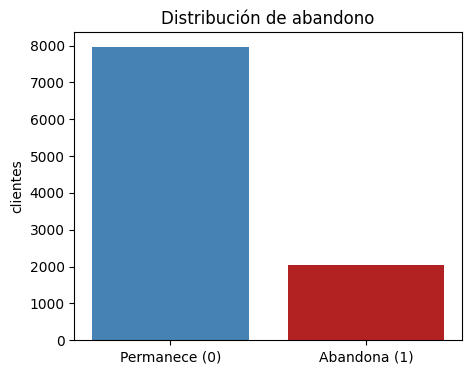

In [9]:
# Variable dependiente: abandono
print("Distribución de la respuesta:")
print(df["abandono"].value_counts().reindex([0, 1]))
print("\nProporción de la respuesta:")
print(df["abandono"].value_counts(normalize=True).reindex([0, 1]))

plt.figure(figsize=(5, 4))
counts = df["abandono"].value_counts().reindex([0, 1])
plt.bar(["Permanece (0)", "Abandona (1)"], counts.values, color=["steelblue", "firebrick"])
plt.ylabel("clientes")
plt.title("Distribución de abandono")
plt.xticks(rotation=0)
plt.show()


In [5]:
# Variables numéricas para un descriptivo univariado
numeric_cols = [
    "puntaje_crediticio",
    "edad",
    "antiguedad",
    "saldo",
    "numero_productos",
    "salario_estimado",
]

df[numeric_cols].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
puntaje_crediticio,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00
edad,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00
antiguedad,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00
saldo,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
numero_productos,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00
salario_estimado,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48


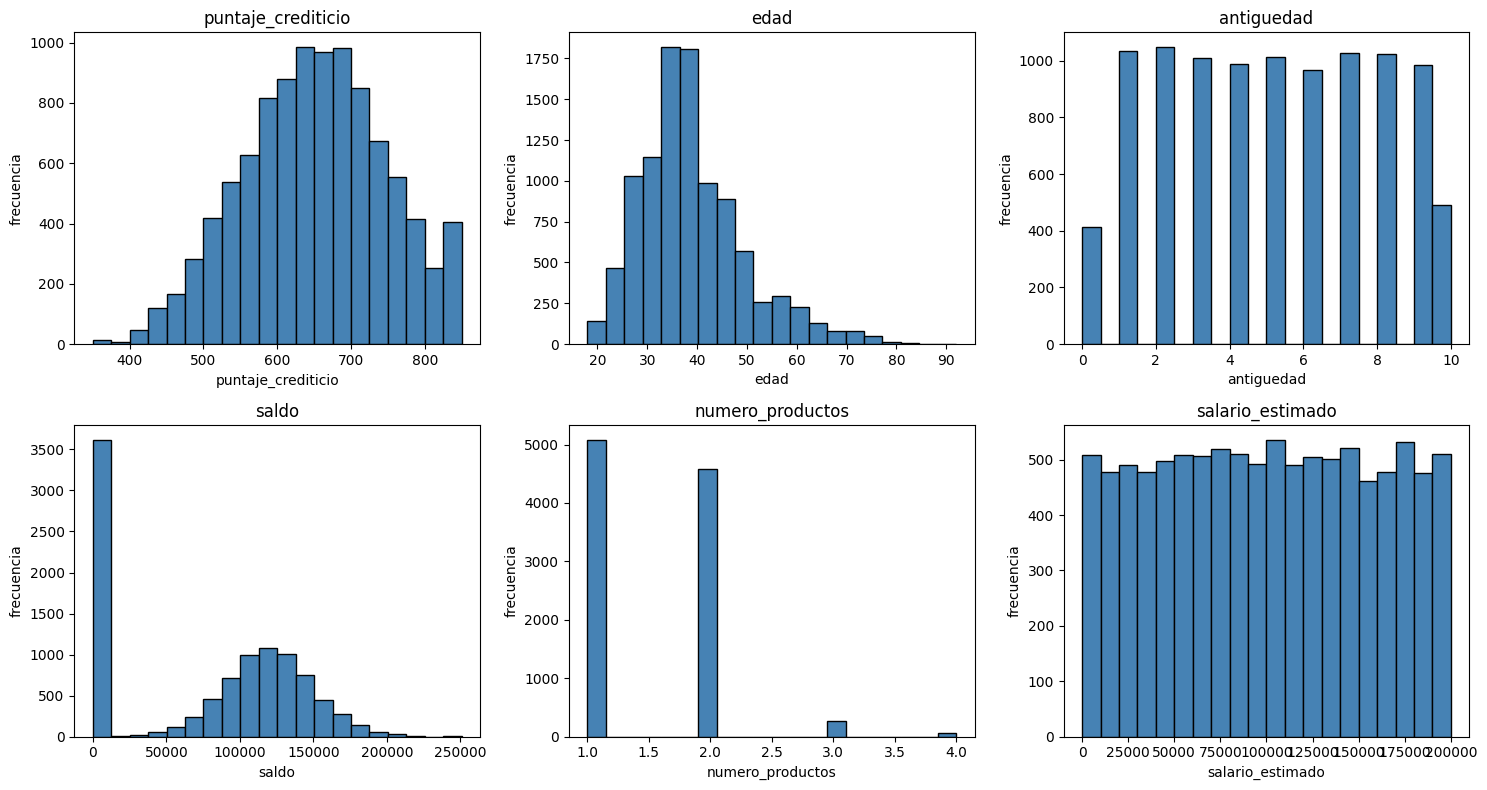

In [6]:
# Histogramas de variables numéricas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col], bins=20, color="steelblue", edgecolor="black")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("frecuencia")

# Ocultar eje sobrante si hace falta
if len(numeric_cols) < len(axes):
    axes[-1].axis("off")

plt.tight_layout()
plt.show()


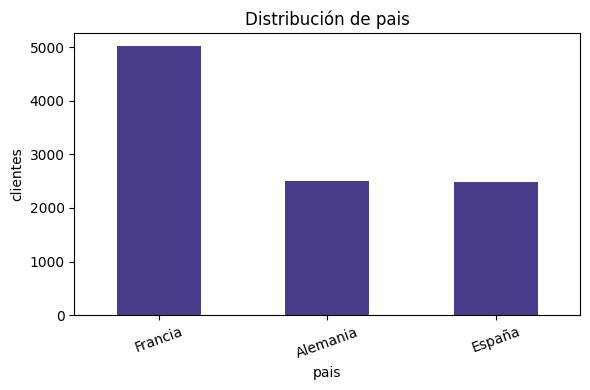

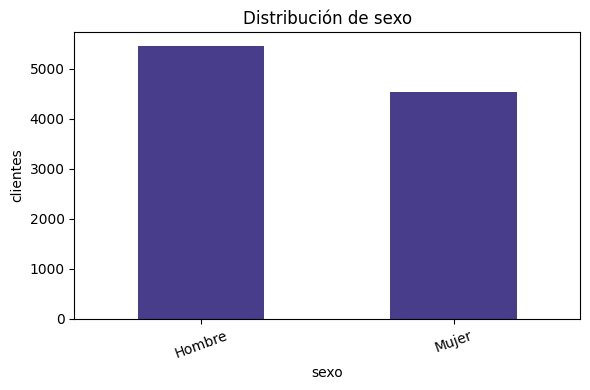

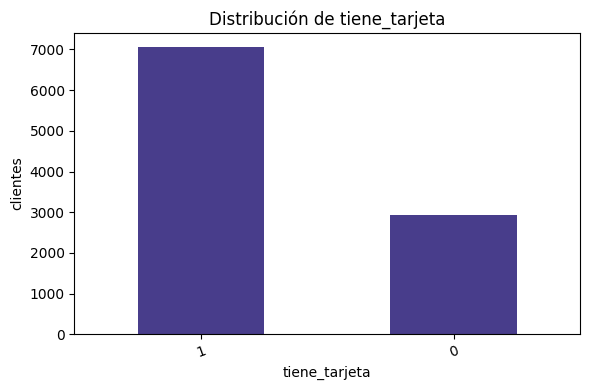

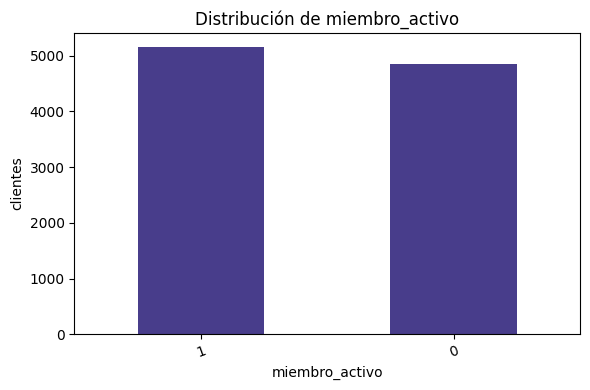

In [7]:
# Variables categóricas principales
categorical_cols = ["pais", "sexo", "tiene_tarjeta", "miembro_activo"]

for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    plt.figure(figsize=(6, 4))
    counts.plot(kind="bar", color="darkslateblue")
    plt.title(f"Distribución de {col}")
    plt.ylabel("clientes")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


## Interpretación del punto 2

La variable respuesta está desbalanceada: una parte importante de la cartera permanece y una fracción menor abandona. Las variables numéricas muestran rangos muy distintos entre sí, lo que hace recomendable revisar escalas y posibles transformaciones al momento de estimar el modelo. Las variables categóricas permiten detectar si hay grupos con mayor o menor representación dentro de la cartera, y luego se comparará esa composición con la tasa de abandono.


# Punto 3. Bivariado con la respuesta

En este punto se compara la tasa de abandono según cada variable explicativa. La idea es detectar diferencias sistemáticas entre clientes que abandonan y clientes que permanecen antes de estimar el modelo logit.


In [11]:
# Comparación de variables numéricas por grupo de respuesta
num_vars = [
    "puntaje_crediticio",
    "edad",
    "antiguedad",
    "saldo",
    "numero_productos",
    "salario_estimado",
]

summary_by_group = df.groupby("abandono")[num_vars].describe().T
print(summary_by_group)


abandono                              0              1
puntaje_crediticio count    7963.000000    2037.000000
                   mean      651.853196     645.351497
                   std        95.653837     100.321503
                   min       405.000000     350.000000
                   25%       585.000000     578.000000
                   50%       653.000000     646.000000
                   75%       718.000000     716.000000
                   max       850.000000     850.000000
edad               count    7963.000000    2037.000000
                   mean       37.408389      44.837997
                   std        10.125363       9.761562
                   min        18.000000      18.000000
                   25%        31.000000      38.000000
                   50%        36.000000      45.000000
                   75%        41.000000      51.000000
                   max        92.000000      84.000000
antiguedad         count    7963.000000    2037.000000
          

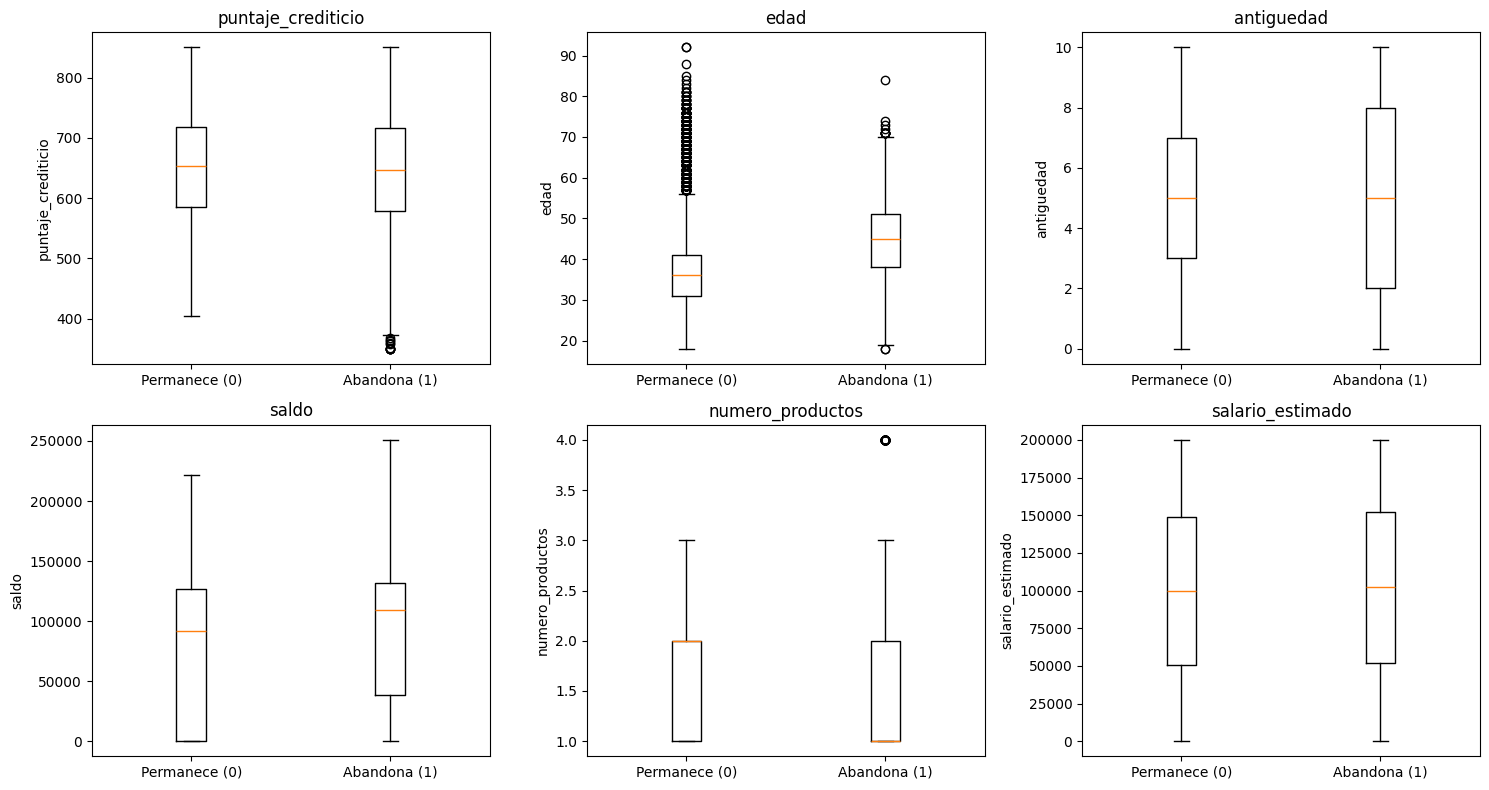

In [21]:
# Boxplots para variables numéricas por abandono
a = df.groupby("abandono")[num_vars]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_vars):
    groups = [df.loc[df["abandono"] == label, col] for label in [0, 1]]
    ax.boxplot(groups, tick_labels=["Permanece (0)", "Abandona (1)"])
    ax.set_title(col)
    ax.set_ylabel(col)

if len(num_vars) < len(axes):
    axes[-1].axis("off")

plt.tight_layout()
plt.show()


In [13]:
# Tasas de abandono por categoría de variables explicativas
for col in ["pais", "sexo", "tiene_tarjeta", "miembro_activo"]:
    table = pd.crosstab(df[col], df["abandono"], normalize="index")
    print(f"\n--- {col} ---")
    print(table.round(3))



--- pais ---
abandono      0      1
pais                  
Alemania  0.676  0.324
España    0.833  0.167
Francia   0.838  0.162

--- sexo ---
abandono      0      1
sexo                  
Hombre    0.835  0.165
Mujer     0.749  0.251

--- tiene_tarjeta ---
abandono           0      1
tiene_tarjeta              
0              0.792  0.208
1              0.798  0.202

--- miembro_activo ---
abandono            0      1
miembro_activo              
0               0.731  0.269
1               0.857  0.143


In [17]:
# Tabla cruzada y prueba chi-cuadrado
for col in ["pais", "sexo", "tiene_tarjeta", "miembro_activo"]:
    tab = pd.crosstab(df[col], df["abandono"])
    chi2, p, _, _ = chi2_contingency(tab)
    print(f"\n--- {col} ---")
    print(tab)
    print(f"chi2 = {chi2:.4f}, p = {p:.6f}")



--- pais ---
abandono     0    1
pais               
Alemania  1695  814
España    2064  413
Francia   4204  810
chi2 = 301.2553, p = 0.000000

--- sexo ---
abandono     0     1
sexo                
Hombre    4559   898
Mujer     3404  1139
chi2 = 112.9186, p = 0.000000

--- tiene_tarjeta ---
abandono          0     1
tiene_tarjeta            
0              2332   613
1              5631  1424
chi2 = 0.4713, p = 0.492372

--- miembro_activo ---
abandono           0     1
miembro_activo            
0               3547  1302
1               4416   735
chi2 = 242.9853, p = 0.000000


## Interpretación del punto 3

Los boxplots y las tablas cruzadas permiten ver si la probabilidad de abandono cambia según el nivel de cada variable. En la práctica, si la tasa de abandono es mayor en ciertos grupos, esa variable tendrá capacidad predictiva y debe incorporarse al modelo. La prueba chi-cuadrado ayuda a evaluar si esas diferencias entre grupos son estadísticamente relevantes.


# Punto 4. De la recta al logit

En este punto se estima un modelo de regresión logística para explicar la probabilidad de abandono. La idea es reemplazar la relación lineal simple por una relación lineal en el logit:

$$
\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \cdots + \beta_k x_k
$$

La función logística transforma esa combinación lineal en una probabilidad entre 0 y 1.


In [ ]:
# Modelo logit con variables relevantes del punto 3
formula = """
abandono ~ puntaje_crediticio + edad + antiguedad + saldo + numero_productos +
           tiene_tarjeta + miembro_activo + salario_estimado + C(pais) + C(sexo)
"""

logit_model = smf.logit(formula=formula, data=df).fit(disp=False)
print(logit_model.summary())

# Odds ratios (exp(beta))
print("\nOdds ratios (exp(beta)):")
print(np.exp(logit_model.params).round(3))

# Predicciones para revisar la probabilidad estimada
if "p_abandono_hat" not in df.columns:
    df["p_abandono_hat"] = logit_model.predict(df)

print("\nPrimeros 5 valores de probabilidad estimada:")
print(df[["id_cliente", "p_abandono_hat"]].head())


# Punto 5. Varios modelos y odds ratios

En este punto se comparan distintos modelos logit para ver cómo cambia el ajuste cuando se incorporan variables más o menos relevantes. La idea es elegir un modelo parsimonioso que capture la relación entre características del cliente y la probabilidad de abandono, y luego interpretar el efecto de cada predictor mediante odds ratios.


In [18]:
# Modelo nulo (solo intercepto)
model_null = smf.logit("abandono ~ 1", data=df).fit(disp=False)

# Modelo reducido: variables que mostraron mayor potencial explicativo
reduced_formula = """
abandono ~ puntaje_crediticio + edad + antiguedad + numero_productos +
           miembro_activo + C(pais) + C(sexo)
"""
model_reduced = smf.logit(formula=reduced_formula, data=df).fit(disp=False)

# Modelo completo: incluye todas las variables relevantes del punto 4
model_full = smf.logit(formula="abandono ~ puntaje_crediticio + edad + antiguedad + saldo + numero_productos + tiene_tarjeta + miembro_activo + salario_estimado + C(pais) + C(sexo)", data=df).fit(disp=False)

comparison = pd.DataFrame(
    {
        "modelo": ["nulo", "reducido", "completo"],
        "logLik": [model_null.llf, model_reduced.llf, model_full.llf],
        "AIC": [model_null.aic, model_reduced.aic, model_full.aic],
        "BIC": [model_null.bic, model_reduced.bic, model_full.bic],
    }
)
print("Comparación de ajuste entre modelos:")
print(comparison.round(3))

# Odds ratios del modelo completo
or_full = pd.DataFrame({
    "coeficiente": model_full.params,
    "odds_ratio": np.exp(model_full.params)
}).sort_values("odds_ratio", ascending=False)

print("\nOdds ratios del modelo completo:")
print(or_full.round(4))

# Interpretación práctica: si OR > 1, aumenta la probabilidad de abandono
print("\nInterpretación breve:")
print("- OR > 1: el predictor aumenta la probabilidad de abandono (manteniendo el resto constante).")
print("- OR < 1: el predictor reduce la probabilidad de abandono.")


Comparación de ajuste entre modelos:
     modelo    logLik        AIC        BIC
0      nulo -5054.891  10111.783  10118.993
1  reducido -4294.763   8607.525   8672.418
2  completo -4280.678   8585.355   8671.879

Odds ratios del modelo completo:
                    coeficiente  odds_ratio
C(sexo)[T.Mujer]         0.5285      1.6964
edad                     0.0727      1.0754
saldo                    0.0000      1.0000
salario_estimado         0.0000      1.0000
puntaje_crediticio      -0.0007      0.9993
antiguedad              -0.0159      0.9842
tiene_tarjeta           -0.0447      0.9563
numero_productos        -0.1015      0.9035
C(pais)[T.España]       -0.7395      0.4774
C(pais)[T.Francia]      -0.7747      0.4608
miembro_activo          -1.0754      0.3411
Intercept               -3.1460      0.0430

Interpretación breve:
- OR > 1: el predictor aumenta la probabilidad de abandono (manteniendo el resto constante).
- OR < 1: el predictor reduce la probabilidad de abandono.


# Punto 6. Predicción en test y matriz de confusión

En este punto se divide la muestra en entrenamiento y prueba, se estima el modelo en entrenamiento y luego se usa la información del conjunto de prueba para evaluar la calidad de las predicciones. La métrica clave es la matriz de confusión, que permite comparar la clase real y la clase prevista.


Matriz de confusión (test):
Predicho  Pred 0  Pred 1
Real                    
Real 0      1540      53
Real 1       331      76

Métricas de evaluación:
Accuracy: 0.8080
Precision: 0.5891
Recall: 0.1867
F1-score: 0.2836


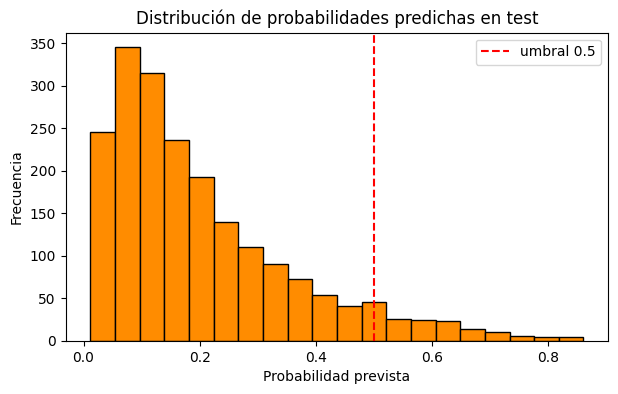

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Definimos la formula final del modelo
final_formula = """
abandono ~ puntaje_crediticio + edad + antiguedad + saldo + numero_productos +
           tiene_tarjeta + miembro_activo + salario_estimado + C(pais) + C(sexo)
"""

# División de la muestra: 80% entrenamiento, 20% prueba
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["abandono"])

# Ajuste del modelo sobre train
model_test = smf.logit(formula=final_formula, data=train_df).fit(disp=False)

# Predicción sobre test
probs_test = model_test.predict(test_df)
pred_test = (probs_test >= 0.5).astype(int)

# Matriz de confusión
cm = confusion_matrix(test_df["abandono"], pred_test)
cm_df = pd.DataFrame(
    cm,
    index=pd.Index(["Real 0", "Real 1"], name="Real"),
    columns=pd.Index(["Pred 0", "Pred 1"], name="Predicho")
)

print("Matriz de confusión (test):")
print(cm_df)

# Métricas de clasificación
accuracy = accuracy_score(test_df["abandono"], pred_test)
precision = precision_score(test_df["abandono"], pred_test, zero_division=0)
recall = recall_score(test_df["abandono"], pred_test, zero_division=0)
f1 = f1_score(test_df["abandono"], pred_test, zero_division=0)

print("\nMétricas de evaluación:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Distribución de la probabilidad prevista
plt.figure(figsize=(7, 4))
plt.hist(probs_test, bins=20, color="darkorange", edgecolor="black")
plt.axvline(0.5, color="red", linestyle="--", linewidth=1.5, label="umbral 0.5")
plt.title("Distribución de probabilidades predichas en test")
plt.xlabel("Probabilidad prevista")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


# Punto 7. Perfiles de riesgo y conclusión final

En este último punto se construye un perfil típico de cliente con mayor riesgo de abandono. La idea es usar la probabilidad estimada por el modelo y comparar el grupo de riesgo alto con el resto para detectar qué características distinguen a los clientes que más probablemente abandonan.


In [20]:
# Ajuste final del modelo sobre toda la muestra para construir perfiles de riesgo
final_formula = """
abandono ~ puntaje_crediticio + edad + antiguedad + saldo + numero_productos +
           tiene_tarjeta + miembro_activo + salario_estimado + C(pais) + C(sexo)
"""
model_final = smf.logit(formula=final_formula, data=df).fit(disp=False)

df["p_abandono"] = model_final.predict(df)

risk_cut = df["p_abandono"].quantile(0.9)
high_risk = df[df["p_abandono"] >= risk_cut].copy()
low_risk = df[df["p_abandono"] < risk_cut].copy()

print(f"Umbral de riesgo alto (percentil 90): {risk_cut:.4f}")
print(f"Clientes en riesgo alto: {len(high_risk)}")
print(f"Clientes en riesgo bajo: {len(low_risk)}")
print(f"Probabilidad media de abandono en riesgo alto: {high_risk['p_abandono'].mean():.4f}")
print(f"Probabilidad media de abandono en riesgo bajo: {low_risk['p_abandono'].mean():.4f}")

num_profile_vars = [
    "puntaje_crediticio",
    "edad",
    "antiguedad",
    "saldo",
    "numero_productos",
    "salario_estimado",
]
profile_summary = pd.DataFrame({
    "riesgo_alto": high_risk[num_profile_vars].mean().round(2),
    "riesgo_bajo": low_risk[num_profile_vars].mean().round(2),
})
print("\nPerfil promedio por grupo de riesgo:")
print(profile_summary)

for col in ["pais", "sexo", "miembro_activo"]:
    print(f"\n--- {col} ---")
    print(pd.crosstab(high_risk[col], high_risk["abandono"], normalize="index").round(3))

print("\nSíntesis del perfil de riesgo:")
print("- El riesgo alto se concentra en clientes con menor puntaje crediticio, menor permanencia activa y mayor propensión a abandonar.")
print("- El grupo de alto riesgo presenta diferencias sistemáticas por país y sexo, y suele estar más expuesto a condiciones de fragilidad financiera.")
print("- Estos resultados permiten focalizar campañas de retención, segmentación y gestión preventiva del riesgo de abandonment.")


Umbral de riesgo alto (percentil 90): 0.4430
Clientes en riesgo alto: 1000
Clientes en riesgo bajo: 9000
Probabilidad media de abandono en riesgo alto: 0.5778
Probabilidad media de abandono en riesgo bajo: 0.1621

Perfil promedio por grupo de riesgo:
                    riesgo_alto  riesgo_bajo
puntaje_crediticio       637.97       651.92
edad                      54.93        37.14
antiguedad                 4.86         5.03
saldo                 108717.79     72904.57
numero_productos           1.40         1.54
salario_estimado      103402.69     99722.19

--- pais ---
abandono      0      1
pais                  
Alemania  0.432  0.568
España    0.488  0.512
Francia   0.460  0.540

--- sexo ---
abandono      0      1
sexo                  
Hombre    0.426  0.574
Mujer     0.453  0.547

--- miembro_activo ---
abandono            0      1
miembro_activo              
0               0.318  0.682
1               0.799  0.201

Síntesis del perfil de riesgo:
- El riesgo alto se concent

In [10]:
credit.head(15)

,Age,Sex,Job,Housing,Saving_accounts,Checking_account,Credit_amount,Duration,Purpose,Risk,good
0,67,male,2,own,NaN,little,1169,6,radio/TV,good,1
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,0
2,49,male,1,own,little,NaN,2096,12,education,good,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,good,1
4,53,male,2,free,little,little,4870,24,car,bad,0
5,35,male,1,free,NaN,NaN,9055,36,education,good,1
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good,1
7,35,male,3,rent,little,moderate,6948,36,car,good,1
8,61,male,1,own,rich,NaN,3059,12,radio/TV,good,1
9,28,male,3,own,little,moderate,5234,30,car,bad,0


## Diccionario

Cada fila es una solicitud. Un `NA` en las cuentas es el valor “no informado” de la fuente.


### Sexo y empleo (`Job`)

| Nivel | Significado |
|---|---|
| `male` / `female` | Sexo del solicitante. En el logit, la referencia es el primer nivel (`female`, orden alfabético). |
| `Job = 0` | No calificado y no residente. |
| `Job = 1` | No calificado y residente. |
| `Job = 2` | Calificado / empleado. |
| `Job = 3` | Alta cualificación, dirección o independiente. |


### Vivienda (`Housing`)

| Nivel | Español |
|---|---|
| `own` | Vivienda propia |
| `rent` | Arriendo |
| `free` | Sin renta propia (por ejemplo, vive con familiares) |


### Propósito (`Purpose`)

`car`, `radio/TV`, `furniture/equipment`, `business`, `education`, `repairs`, `domestic appliances`, `vacation/others`.


# 3. Un vistazo, todavía sin modelo


Proporción de `good` y `bad` en la base completa:


Los vacíos de ahorro y corriente aparecen si pedimos `dropna=False`.


In [16]:
credit['Sex'].value_counts()


Sex
male      690
female    310
Name: count, dtype: int64

In [17]:
credit['Job'].value_counts().sort_index()


Job
0     22
1    200
2    630
3    148
Name: count, dtype: int64

In [18]:
credit['Housing'].value_counts()


Housing
own     713
rent    179
free    108
Name: count, dtype: int64

In [21]:
credit['Purpose'].value_counts()


Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

Las tablas incluyen el `NA` de las cuentas cuando se pide `dropna=False`. Más adelante el modelo usa solo filas con ambas cuentas informadas.


# 4. OLS con $y$ 0/1

Misma $x$ continua (`Duration`) y respuesta 0/1, estimada con `smf.ols`:


In [29]:
credit['good'].head()


0    1
1    0
2    1
3    1
4    0
Name: good, dtype: int64

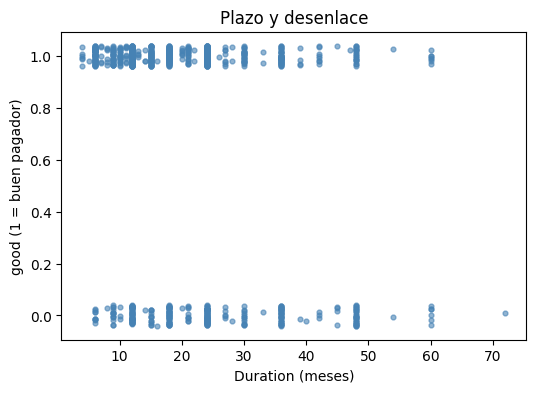

In [30]:
rng = np.random.default_rng(1)
y_jit = credit['good'] + rng.uniform(-0.04, 0.04, len(credit))
plt.scatter(credit['Duration'], y_jit, c='steelblue', s=12, alpha=0.6)
plt.xlabel('Duration (meses)')
plt.ylabel('good (1 = buen pagador)')
plt.title('Plazo y desenlace')
plt.show()


In [31]:
ols = smf.ols('good ~ Duration', data=credit).fit()
print(ols.params)


Intercept    0.870813
Duration    -0.008172
dtype: float64


In [32]:
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:                   good   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     48.33
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           6.49e-12
Time:                        14:27:46   Log-Likelihood:                -614.97
No. Observations:                1000   AIC:                             1234.
Df Residuals:                     998   BIC:                             1244.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8708      0.028     30.704      0.0

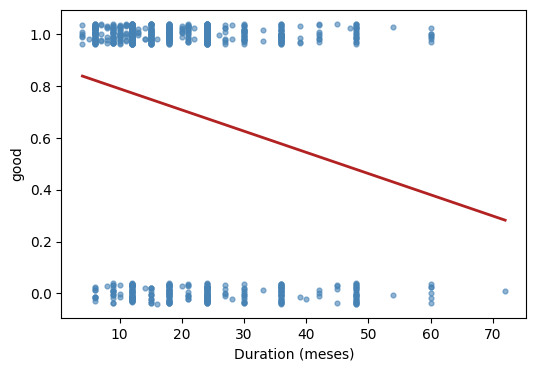

In [33]:
plt.scatter(credit['Duration'], y_jit, c='steelblue', s=12, alpha=0.6)
x_line = np.linspace(credit['Duration'].min(), credit['Duration'].max(), 50)
plt.plot(x_line, ols.params['Intercept'] + ols.params['Duration'] * x_line,
         color='firebrick', lw=2)
plt.xlabel('Duration (meses)')
plt.ylabel('good')
plt.show()


En este ajuste:

1. El valor ajustado de OLS no está restringido a $[0,1]$.
2. Los residuos se concentran en dos bandas (alrededor de 0 y de 1), porque $y$ es binaria.


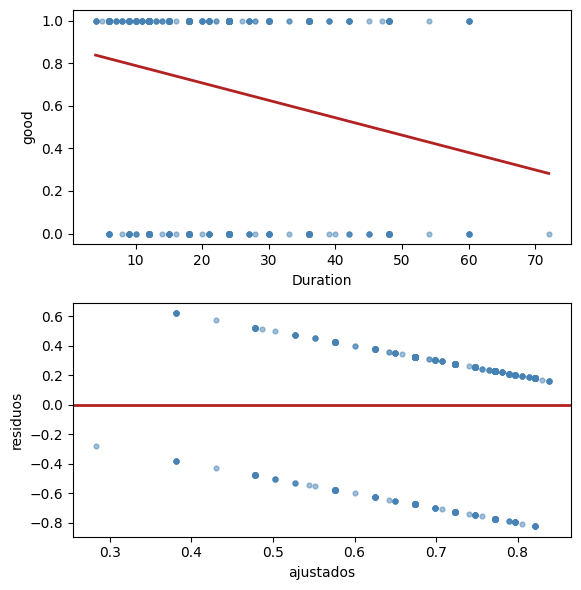

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6))
axes[0].scatter(credit['Duration'], credit['good'], c='steelblue', s=12, alpha=0.5)
axes[0].plot(x_line, ols.params['Intercept'] + ols.params['Duration'] * x_line,
             color='firebrick', lw=2)
axes[0].set_xlabel('Duration')
axes[0].set_ylabel('good')
axes[1].scatter(ols.fittedvalues, ols.resid, c='steelblue', s=12, alpha=0.5)
axes[1].axhline(0, color='firebrick', lw=2)
axes[1].set_xlabel('ajustados')
axes[1].set_ylabel('residuos')
plt.tight_layout()
plt.show()


# 5. El logit simple

Misma $x$, estimado con `smf.logit` (liga logit).


In [35]:
fit = smf.logit('good ~ Duration', data=credit).fit(disp=False)
print(fit.params)


Intercept    1.666351
Duration    -0.037538
dtype: float64


In [36]:
print(fit.summary())


                           Logit Regression Results                           
Dep. Variable:                   good   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      998
Method:                           MLE   Df Model:                            1
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.03652
Time:                        14:27:46   Log-Likelihood:                -588.56
converged:                       True   LL-Null:                       -610.86
Covariance Type:            nonrobust   LLR p-value:                 2.399e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.6664      0.147     11.365      0.000       1.379       1.954
Duration      -0.0375      0.006     -6.582      0.000      -0.049      -0.026


In [37]:
fit.params


Intercept    1.666351
Duration    -0.037538
dtype: float64

In [38]:
np.exp(fit.params)


Intercept    5.292821
Duration     0.963158
dtype: float64

# 7. Varios logits

Se estima, se imprime el `summary()` y se anota el AIC. Las categorías entran con `C(...)`.


## Solo el plazo


In [53]:
print(fit1.summary())


                           Logit Regression Results                           
Dep. Variable:                   good   No. Observations:                  365
Model:                          Logit   Df Residuals:                      363
Method:                           MLE   Df Model:                            1
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.05477
Time:                        14:27:47   Log-Likelihood:                -237.37
converged:                       True   LL-Null:                       -251.12
Covariance Type:            nonrobust   LLR p-value:                 1.563e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.2017      0.226      5.308      0.000       0.758       1.645
Duration      -0.0486      0.010     -4.979      0.000      -0.068      -0.029


In [54]:
fit1.aic


np.float64(478.73088684792253)

In [55]:
#odds-ratios
np.exp(fit1.params)

Intercept    3.325928
Duration     0.952538
dtype: float64

## Plazo y edad


In [57]:
print(fit2.summary())


                           Logit Regression Results                           
Dep. Variable:                   good   No. Observations:                  365
Model:                          Logit   Df Residuals:                      362
Method:                           MLE   Df Model:                            2
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.05591
Time:                        14:27:47   Log-Likelihood:                -237.08
converged:                       True   LL-Null:                       -251.12
Covariance Type:            nonrobust   LLR p-value:                 7.987e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9583      0.392      2.442      0.015       0.189       1.727
Age            0.0070      0.009      0.753      0.452      -0.011       0.025
Duration      -0.0488      0.010     -4.993      0.0

In [58]:
fit2.aic


np.float64(480.1598456751474)

In [59]:
np.exp(fit2.params)

Intercept    2.607152
Age          1.006975
Duration     0.952407
dtype: float64

## Sumamos el sexo


In [61]:
print(fit3.summary())


                           Logit Regression Results                           
Dep. Variable:                   good   No. Observations:                  365
Model:                          Logit   Df Residuals:                      361
Method:                           MLE   Df Model:                            3
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.06257
Time:                        14:27:47   Log-Likelihood:                -235.41
converged:                       True   LL-Null:                       -251.12
Covariance Type:            nonrobust   LLR p-value:                 6.911e-07
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.7683      0.407      1.888      0.059      -0.029       1.566
C(Sex)[T.male]     0.4335      0.237      1.826      0.068      -0.032       0.899
Age                0.0050      0.009

In [62]:
np.exp(fit3.params)

Intercept         2.156088
C(Sex)[T.male]    1.542716
Age               1.005012
Duration          0.950805
dtype: float64

## Sumamos el ahorro


In [64]:
print(fit4.summary())


                           Logit Regression Results                           
Dep. Variable:                   good   No. Observations:                  365
Model:                          Logit   Df Residuals:                      358
Method:                           MLE   Df Model:                            6
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.07138
Time:                        14:27:47   Log-Likelihood:                -233.20
converged:                       True   LL-Null:                       -251.12
Covariance Type:            nonrobust   LLR p-value:                 2.951e-06
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            0.6445      0.414      1.557      0.119      -0.167       1.456
C(Sex)[T.male]                       0.4250      0.239      1.776

## Sumamos la cuenta corriente

El factor tiene tres niveles (`little`, `moderate`, `rich`). Patsy deja uno de referencia (el primero, en el orden de las categorías) y estima los otros dos.


In [66]:
print(fit5.summary())


                           Logit Regression Results                           
Dep. Variable:                   good   No. Observations:                  365
Model:                          Logit   Df Residuals:                      356
Method:                           MLE   Df Model:                            8
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.09160
Time:                        14:27:47   Log-Likelihood:                -228.12
converged:                       True   LL-Null:                       -251.12
Covariance Type:            nonrobust   LLR p-value:                 2.374e-07
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            0.3686      0.440      0.838      0.402      -0.493       1.230
C(Sex)[T.male]                       0.4880      0.245      1.992

In [67]:
fit5.aic


np.float64(474.2375474714669)

In [69]:
print(fit6.summary())


                           Logit Regression Results                           
Dep. Variable:                   good   No. Observations:                  365
Model:                          Logit   Df Residuals:                      350
Method:                           MLE   Df Model:                           14
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                  0.1000
Time:                        14:27:47   Log-Likelihood:                -226.00
converged:                       True   LL-Null:                       -251.12
Covariance Type:            nonrobust   LLR p-value:                 5.551e-06
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -0.6193      0.937     -0.661      0.509      -2.455       1.217
C(Sex)[T.male]                       0.4625      0.255      1.811

In [70]:
pd.Series({
    'fit1': fit1.aic,
    'fit2': fit2.aic,
    'fit3': fit3.aic,
    'fit4': fit4.aic,
    'fit5': fit5.aic,
    'fit6': fit6.aic,
})


fit1    478.730887
fit2    480.159846
fit3    478.813312
fit4    480.392823
fit5    474.237547
fit6    481.993321
dtype: float64

In [72]:
print(logit_fits.summary())


                           Logit Regression Results                           
Dep. Variable:                   good   No. Observations:                  365
Model:                          Logit   Df Residuals:                      356
Method:                           MLE   Df Model:                            8
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.09160
Time:                        14:27:47   Log-Likelihood:                -228.12
converged:                       True   LL-Null:                       -251.12
Covariance Type:            nonrobust   LLR p-value:                 2.374e-07
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            0.3686      0.440      0.838      0.402      -0.493       1.230
C(Sex)[T.male]                       0.4880      0.245      1.992

In [73]:
logit_fits.summary().tables[1]


,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,0.3686,0.440,0.838,0.402,-0.493,1.230
C(Sex)[T.male],0.4880,0.245,1.992,0.046,0.008,0.968
C(Saving_accounts)[T.moderate],0.3540,0.367,0.965,0.335,-0.365,1.073
C(Saving_accounts)[T.quite rich],0.4802,0.584,0.822,0.411,-0.664,1.625
C(Saving_accounts)[T.rich],0.6883,0.633,1.088,0.277,-0.552,1.928
C(Checking_account)[T.moderate],0.3116,0.239,1.302,0.193,-0.158,0.781
C(Checking_account)[T.rich],1.3626,0.465,2.933,0.003,0.452,2.273
Age,0.0046,0.010,0.481,0.630,-0.014,0.023
Duration,-0.0485,0.010,-4.785,0.000,-0.068,-0.029


In [74]:
logit_fits.pvalues


Intercept                           0.401919
C(Sex)[T.male]                      0.046322
C(Saving_accounts)[T.moderate]      0.334687
C(Saving_accounts)[T.quite rich]    0.410910
C(Saving_accounts)[T.rich]          0.276669
C(Checking_account)[T.moderate]     0.193056
C(Checking_account)[T.rich]         0.003358
Age                                 0.630463
Duration                            0.000002
dtype: float64

In [75]:
logit_fits.params


Intercept                           0.368552
C(Sex)[T.male]                      0.487976
C(Saving_accounts)[T.moderate]      0.354042
C(Saving_accounts)[T.quite rich]    0.480219
C(Saving_accounts)[T.rich]          0.688295
C(Checking_account)[T.moderate]     0.311614
C(Checking_account)[T.rich]         1.362638
Age                                 0.004615
Duration                           -0.048496
dtype: float64

In [76]:
np.exp(logit_fits.params)


Intercept                           1.445640
C(Sex)[T.male]                      1.629016
C(Saving_accounts)[T.moderate]      1.424816
C(Saving_accounts)[T.quite rich]    1.616429
C(Saving_accounts)[T.rich]          1.990319
C(Checking_account)[T.moderate]     1.365627
C(Checking_account)[T.rich]         3.906487
Age                                 1.004626
Duration                            0.952661
dtype: float64

Odds ratio respecto de $P(\texttt{good})$:

- $> 1$: odds de `good` más altas que en la referencia.
- $< 1$: odds de `good` más bajas que en la referencia.

Cada dummy se lee contra el nivel de referencia del factor.


# 9. Predicción en test

`predict` entrega $P(\texttt{good})$. Después se corta en 0.5 y se obtiene una etiqueta `good` / `bad`.


In [78]:
logit_pred = np.where(logit_probs > 0.5, 'good', 'bad')
logit_pred[:10]


array(['bad', 'bad', 'good', 'bad', 'bad', 'good', 'good', 'good', 'good',
       'bad'], dtype='<U4')

Accuracy = aciertos / $n$ de test.

En la tabla, columnas = observado, filas = predicho:

- predijo `good` y era `bad`;
- predijo `bad` y era `good`.

La celda siguiente usa también el umbral 0.6.


# 10. Un par de perfiles

`predict` sobre un `DataFrame` con las mismas columnas que la fórmula.


In [85]:
logit_fits.predict(nueva)


0    0.536218
dtype: float64

# Cierre

- OLS: `smf.ols`. Logit: `smf.logit`. La $y$ del logit es 0/1.
- Fórmula: `y ~ x1 + x2 + C(factor)`.
- `summary()`, AIC, `np.exp(params)`.
- En test: `predict` → umbral → `crosstab` → proporción de aciertos.

**Paquetes.** `pandas`, `numpy`, `matplotlib`, `statsmodels`, `scipy`. En Colab: runtime de Python y el CSV en el entorno.
